
<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 1
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consignas

En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de **B** bits en un rango de $±VF$ Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a **fs** Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una **senoidal contaminada con un nivel predeterminado de ruido**. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

- frecuencia $f_{0}$ arbitraria, por ejemplo $f_{0}=f_{S}/N=Δ_{f}$

- **energía normalizada**, es decir energía (o varianza) unitaria

Con respecto a los parámetros de la secuencia de ruido, diremos que:

- será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n. Siendo n la secuencia que simula la interferencia, y s la senoidal descrita anteriormente.

- La potencia del ruido será $P_{n}=k_{n}.P_{q}$ W siendo el factor k una escala para la potencia del ruido de cuantización Pq=q212.

-  finalmente, n será **incorrelado** y **Gaussiano**.

El ADC que deseamos simular trabajará a una frecuencia de muestreo $f_{S}=1000 Hz$ y tendrá un rango analógico de $±VF=2$ Volts.

Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1
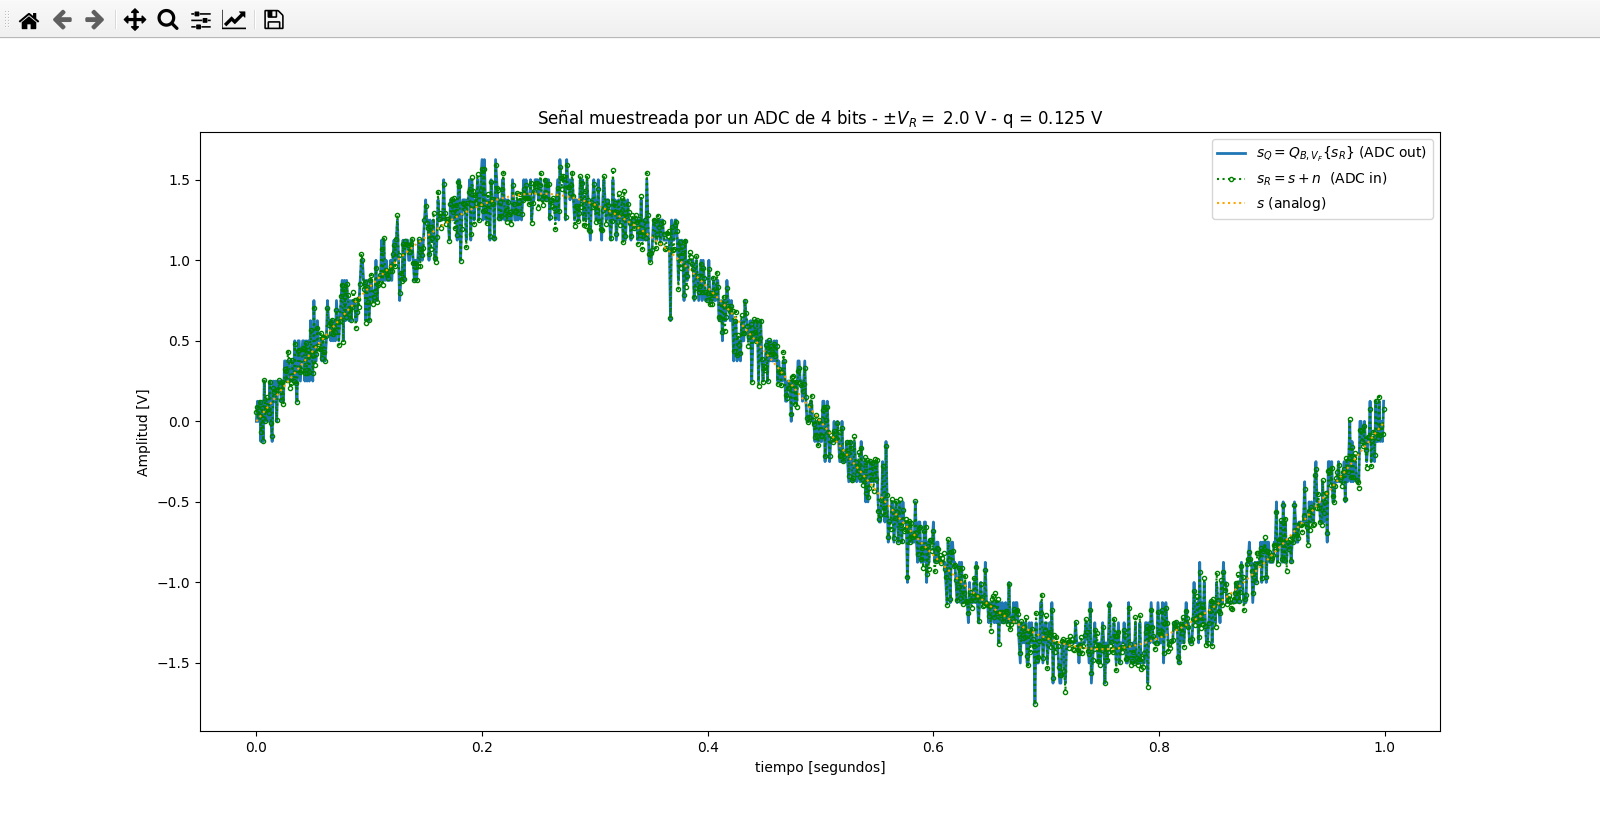
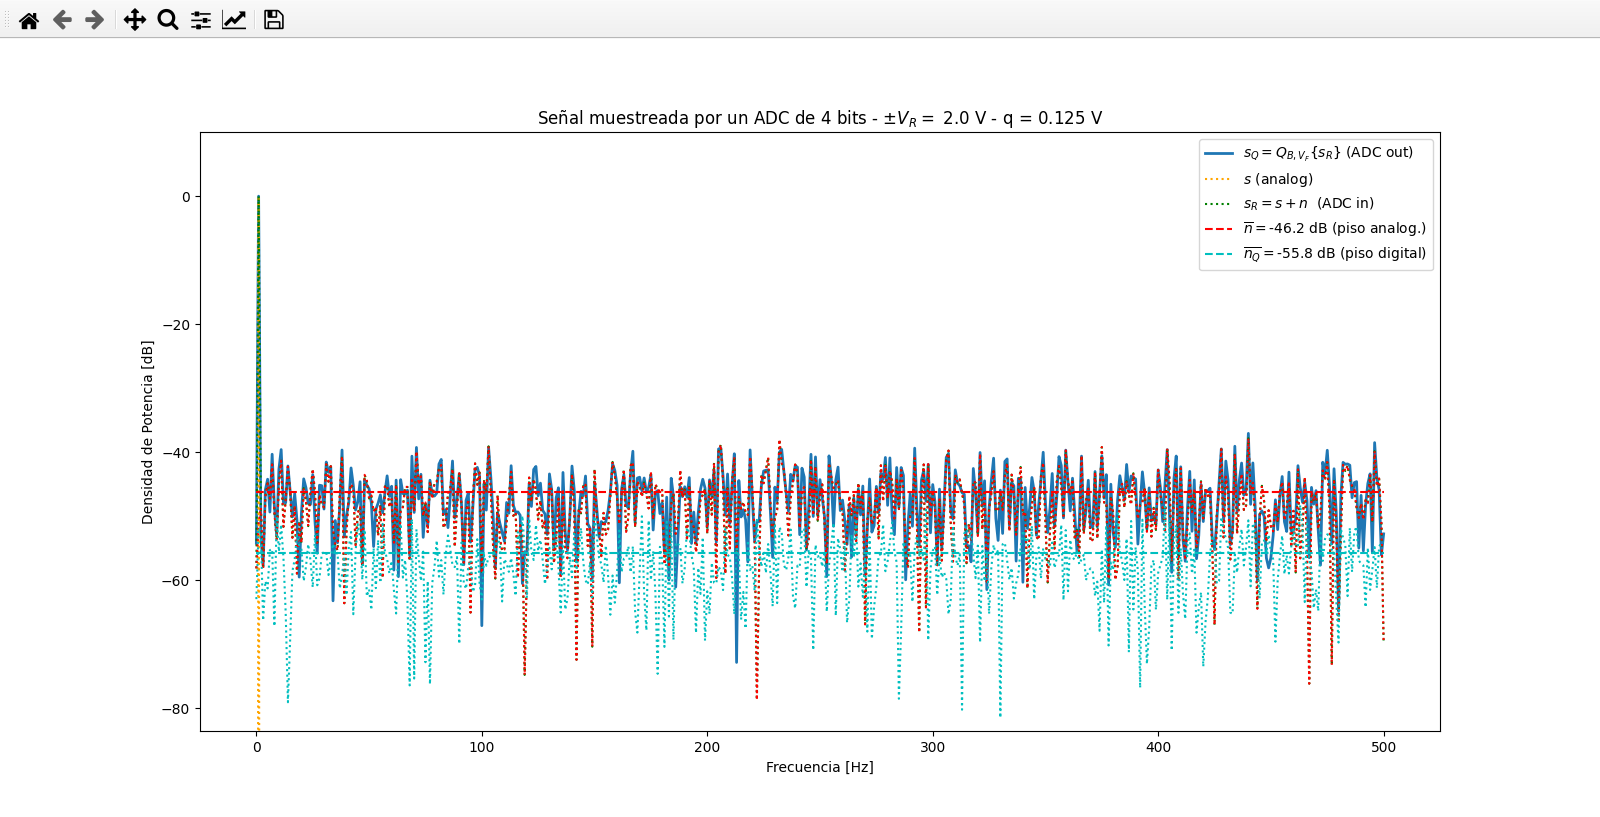
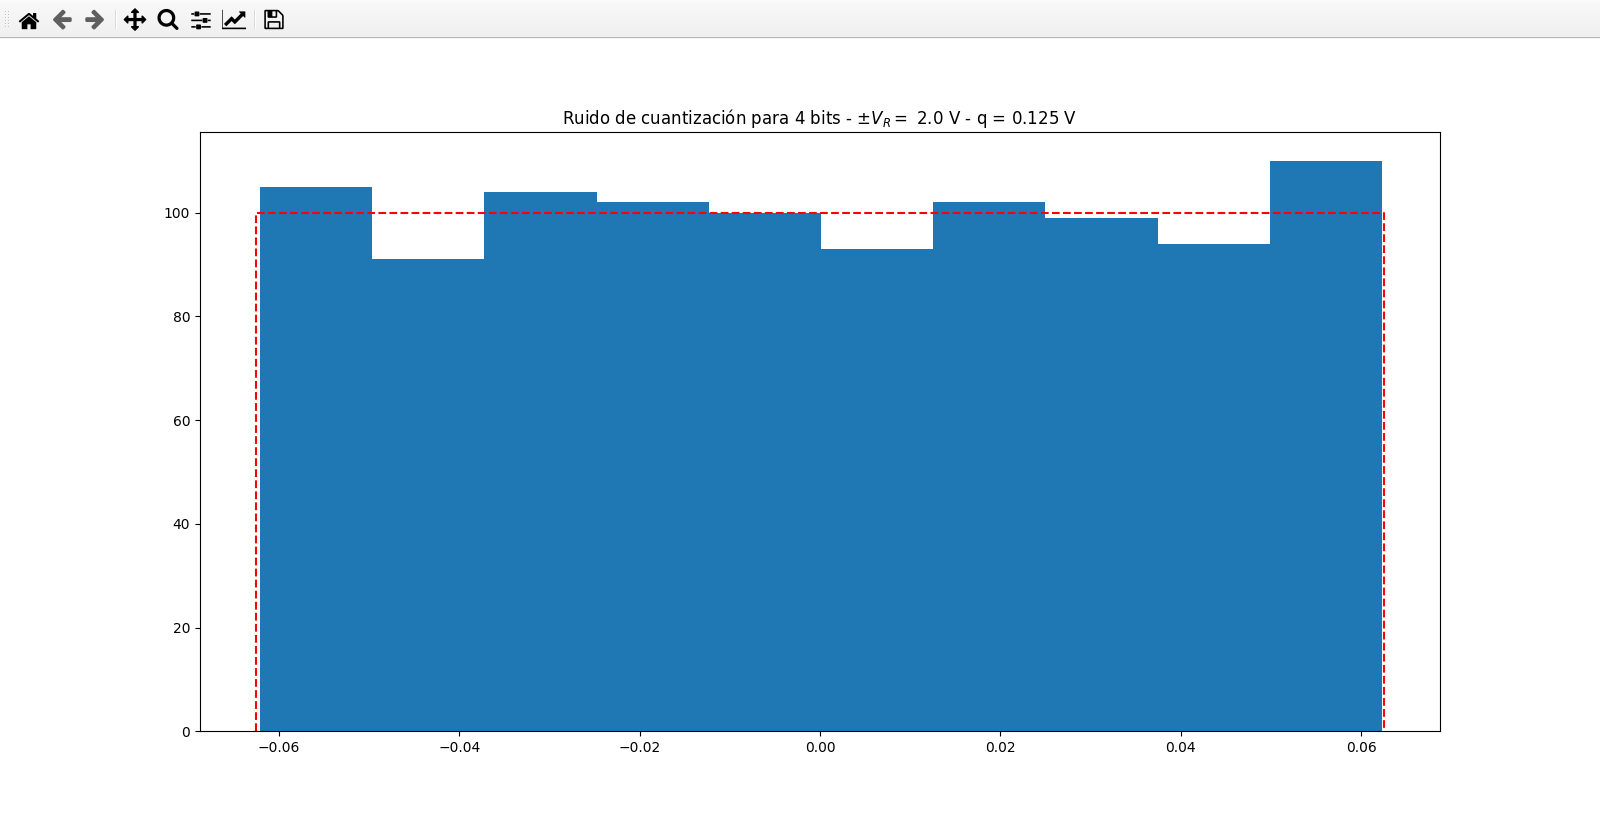

b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}. Discutir los resultados respecto a lo obtenido en a).

Bonus:

- 💎 Encontrar la relación entre la cantidad de B bits del ADC y el SNR de la señal digitalizada. (Ver Holton. DSP Principles and App. 6.7 ADC Quantization pag. 387 )
  
- 🤯 Simular el efecto del aliasing junto con el muestreo.

# Resolución del ejercicio 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Función para sintetizar señales senoidales
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):

    ts = 1/fs

    tt = np.linspace(0, (nn-1)*ts, nn)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    return tt, xx


fs = 1000          # Frecuencia de muestreo (1000 Hz)
N = 1000           
f0 = fs / N        
vmax = np.sqrt(2)  


B = 4              
V_R = 2.0          # Rango analógico +/- 2.0 V
q = (V_R) / (2**B)   # Paso de cuantización
kn = 9             # Factor de escala del ruido de entrada

tt, s = mi_funcion_sen(vmax, 0, f0, 0, N, fs)

Pq = (q**2) / 12   # Potencia del ruido de cuantización teórico
Pn = kn * Pq       # Potencia del ruido analógico

np.random.seed(0)  
n = np.random.normal(0, np.sqrt(Pn), N)

# Señal con ruido
sR = s + n

# Señal cuantizada a la salida del ADC
sQ = np.round(sR / q) * q

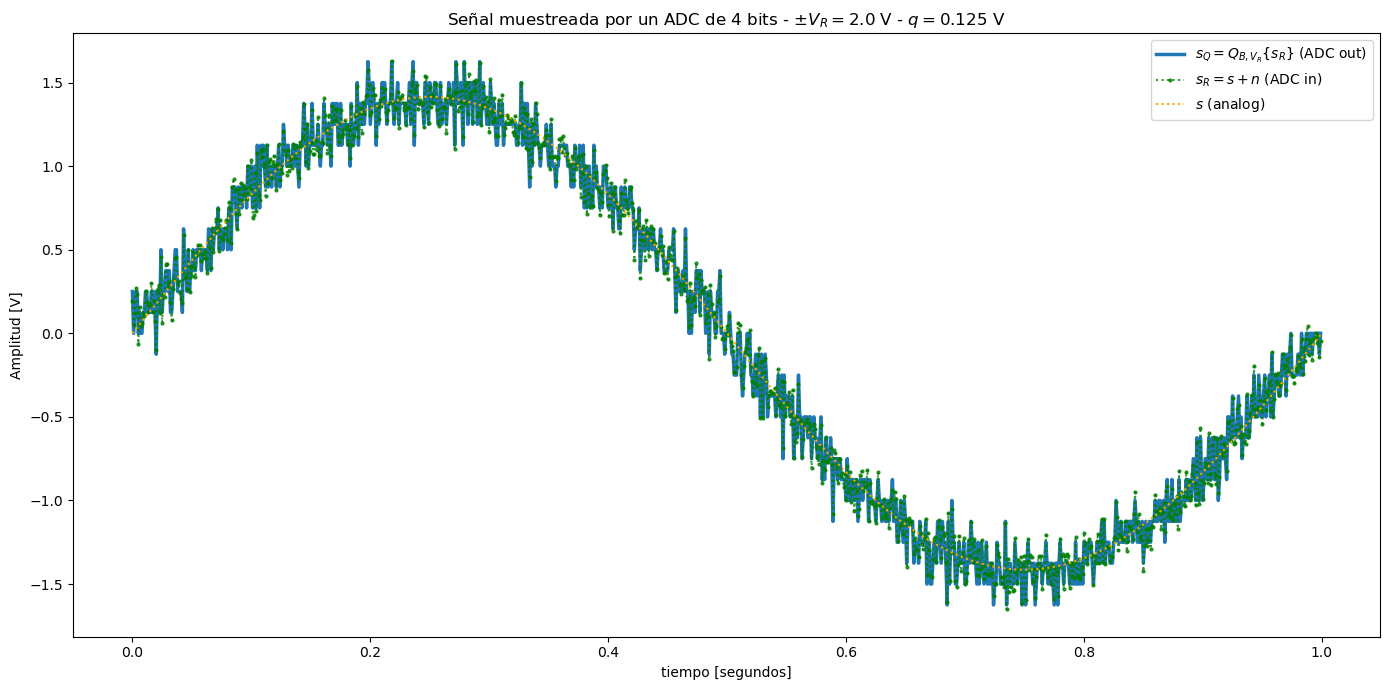

In [2]:
plt.figure(figsize=(14, 7))

plt.plot(tt, sQ, label=r'$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)', linewidth=2.5, color='C0')
plt.plot(tt, sR, 'g.:', label=r'$s_R = s + n$ (ADC in)', markersize=4, alpha=0.8)
plt.plot(tt, s, color='orange', linestyle=':', label=r'$s$ (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits - $\pm V_R = {V_R}$ V - $q = {q}$ V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

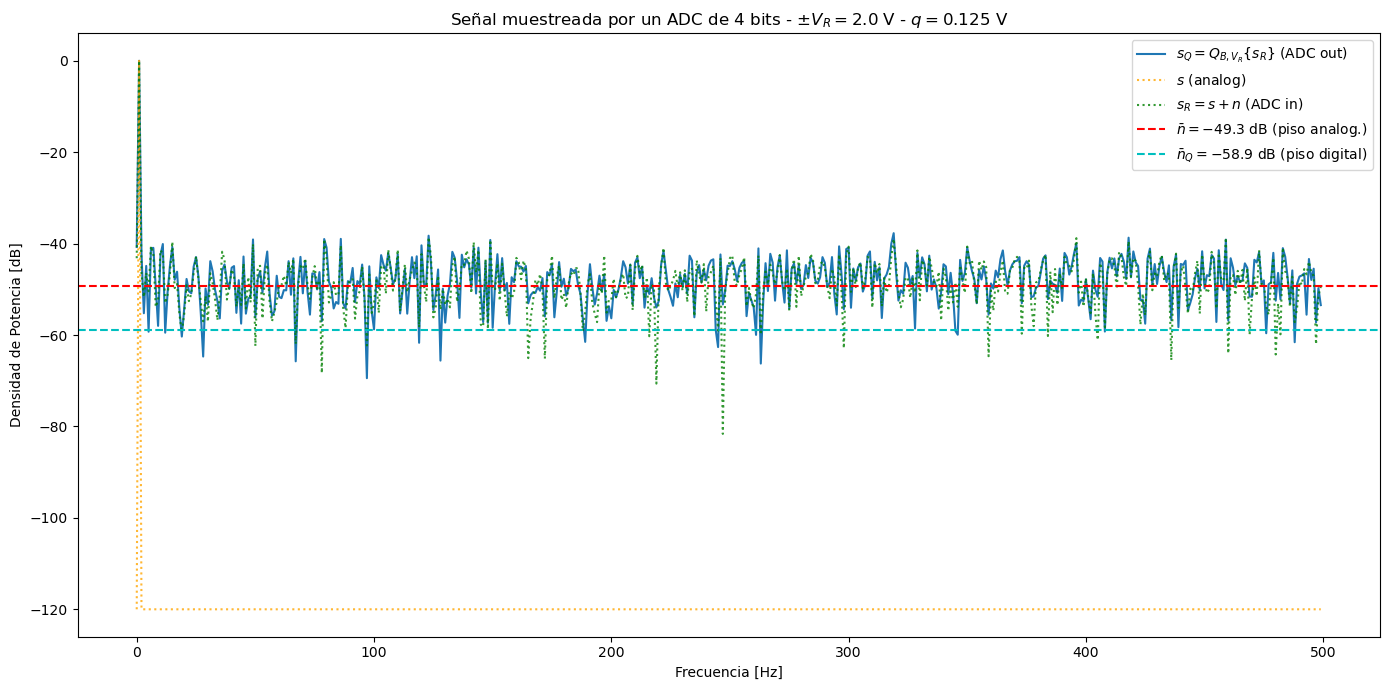

In [3]:
# Transformadas de Fourier normalizadas
S = np.fft.fft(s) / N
SR = np.fft.fft(sR) / N
SQ = np.fft.fft(sQ) / N

# Vector de frecuencias (solo la mitad positiva hasta Nyquist)
freqs = np.fft.fftfreq(N, 1/fs)
pos_freqs = freqs[:N//2]

# Cálculo de Densidad de Potencia en dB
eps = 1e-12 # Pequeña constante para evitar log(0)
psd_s = 10 * np.log10(2 * np.abs(S[:N//2])**2 + eps)
psd_sR = 10 * np.log10(2 * np.abs(SR[:N//2])**2 + eps)
psd_sQ = 10 * np.log10(2 * np.abs(SQ[:N//2])**2 + eps)

# Pisos de ruido teóricos esparcidos en los N/2 bins
floor_digital_dB = 10 * np.log10(Pq / N)
floor_analog_dB = 10 * np.log10(Pn / N)

plt.figure(figsize=(14, 7))

plt.plot(pos_freqs, psd_sQ, label=r'$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)', color='C0')
plt.plot(pos_freqs, psd_s, color='orange', linestyle=':', label=r'$s$ (analog)', alpha=0.8)
plt.plot(pos_freqs, psd_sR, 'g:', label=r'$s_R = s + n$ (ADC in)', alpha=0.8)

plt.axhline(floor_analog_dB, color='r', linestyle='--', label=f'$\\bar{{n}} = {floor_analog_dB:.1f}$ dB (piso analog.)')
plt.axhline(floor_digital_dB, color='c', linestyle='--', label=f'$\\bar{{n}}_Q = {floor_digital_dB:.1f}$ dB (piso digital)')

plt.title(f'Señal muestreada por un ADC de {B} bits - $\pm V_R = {V_R}$ V - $q = {q}$ V')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

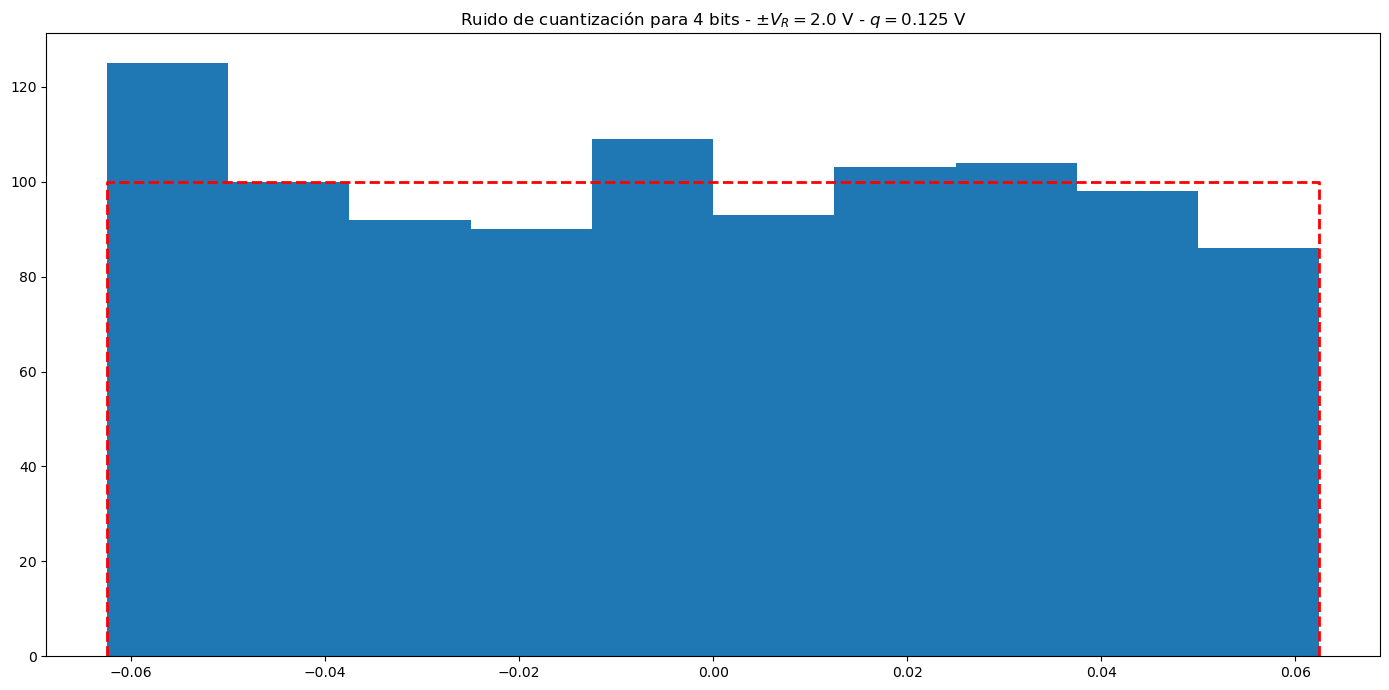

In [4]:
# Cálculo del error de cuantización
eq = sQ - sR

plt.figure(figsize=(14, 7))

counts, bins, patches = plt.hist(eq, bins=10, range=(-q/2, q/2), color='C0')

ideal_count = N / 10
plt.plot([-q/2, -q/2, q/2, q/2], [0, ideal_count, ideal_count, 0], 'r--', linewidth=2)

plt.title(f'Ruido de cuantización para {B} bits - $\pm V_R = {V_R}$ V - $q = {q}$ V')
plt.tight_layout()

plt.show()

# Resolución del ejercicio 2

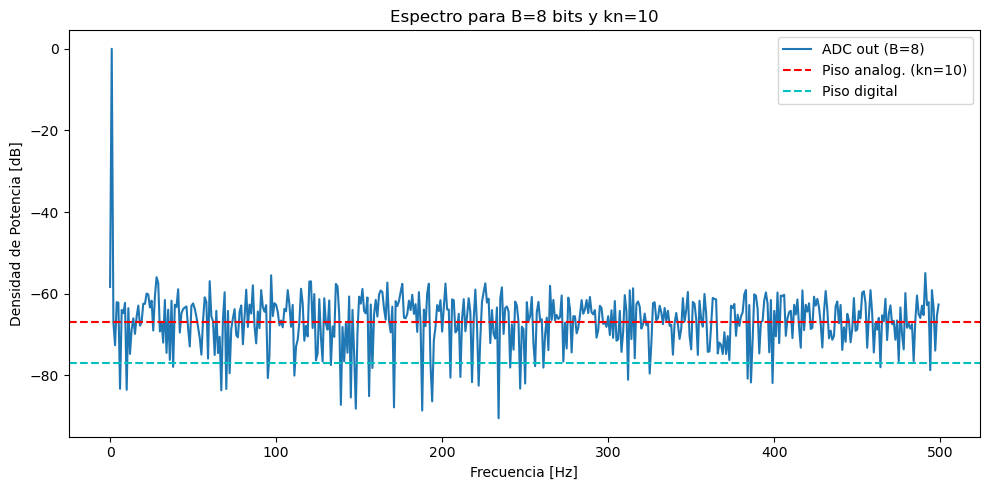

In [7]:

B_test = 8          # 4, 8 o 16
kn_test = 10        # 0.1, 1 o 10


q_test = (2 * V_R) / (2**B_test)
Pq_test = (q_test**2) / 12
Pn_test = kn_test * Pq_test

n_test = np.random.normal(0, np.sqrt(Pn_test), N)
sR_test = s + n_test
sQ_test = np.round(sR_test / q_test) * q_test


SQ_test = np.fft.fft(sQ_test) / N
psd_sQ_test = 10 * np.log10(2 * np.abs(SQ_test[:N//2])**2 + eps)

floor_digital_test = 10 * np.log10(Pq_test / N)
floor_analog_test = 10 * np.log10(Pn_test / N)

plt.figure(figsize=(10, 5))
plt.plot(pos_freqs, psd_sQ_test, label=f'ADC out (B={B_test})', color='C0')
plt.axhline(floor_analog_test, color='r', linestyle='--', label=f'Piso analog. (kn={kn_test})')
plt.axhline(floor_digital_test, color='c', linestyle='--', label=f'Piso digital')
plt.title(f'Espectro para B={B_test} bits y kn={kn_test}')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend()
plt.tight_layout()
plt.show()

Para encontrar la relación teórica entre la Relación Señal a Ruido (SNR) y la cantidad de bits $B$ de un ADC, partimos de la definición de SNR en decibeles asumiendo una señal senoidal a plena escala (full-scale).La amplitud máxima de la senoidal para aprovechar todo el rango es $A = V_R$. Por lo tanto, la potencia de la señal senoidal es:$$P_{signal} = \frac{A^2}{2} = \frac{V_R^2}{2}$$La potencia del ruido de cuantización (asumiendo que es uniforme e incorrelado) es:$$P_{noise} = \frac{q^2}{12}$$Sabiendo que el paso de cuantización es $q = \frac{2 V_R}{2^B}$, reemplazamos en la potencia del ruido:$$P_{noise} = \frac{\left(\frac{2 V_R}{2^B}\right)^2}{12} = \frac{4 V_R^2}{12 \cdot 2^{2B}} = \frac{V_R^2}{3 \cdot 2^{2B}}$$Ahora, calculamos el SNR como el cociente de potencias:$$SNR = \frac{P_{signal}}{P_{noise}} = \frac{V_R^2 / 2}{V_R^2 / (3 \cdot 2^{2B})} = \frac{3}{2} \cdot 2^{2B}$$Pasando esto a decibeles ($10 \log_{10}$):$$SNR_{dB} = 10 \log_{10}(1.5) + 10 \log_{10}(2^{2B})$$$$SNR_{dB} = 1.76 + 20 \cdot B \cdot \log_{10}(2)$$Como $\log_{10}(2) \approx 0.301$, llegamos a la famosa regla de oro de los conversores de datos:$$SNR_{dB} \approx 6.02 \cdot B + 1.76$$Conclusión: Cada bit adicional en el ADC mejora la relación señal-ruido en aproximadamente 6 dB.

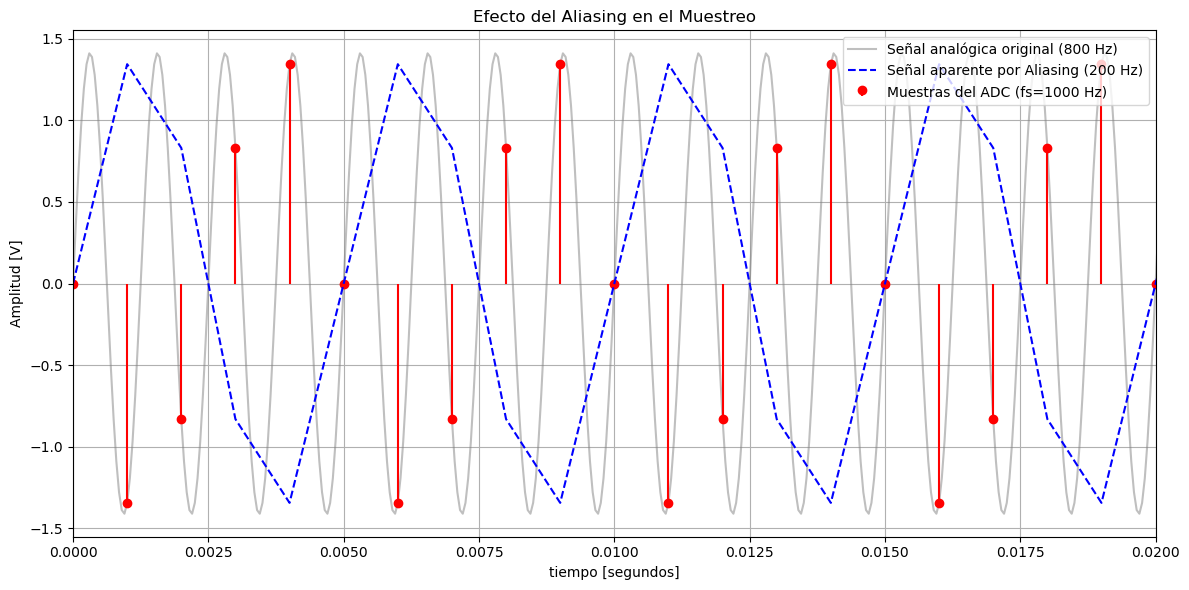

In [8]:

fs_adc = 1000        # Frecuencia de muestreo del ADC
f_in = 800           # Frecuencia de la señal (SUPERIOR a fs/2 = 500Hz)
fs_alta = 20000      # Frecuencia de simulación muy alta para emular el mundo "analógico" y continuo

t_cont, s_cont = mi_funcion_sen(vmax, 0, f_in, 0, 1000, fs_alta)

t_muestreada, s_muestreada = mi_funcion_sen(vmax, 0, f_in, 0, int(len(t_cont)*(fs_adc/fs_alta)), fs_adc)

t_alias, s_alias = mi_funcion_sen(vmax, 0, 200, 0, len(t_muestreada), fs_adc)


plt.figure(figsize=(12, 6))

plt.plot(t_cont, s_cont, 'gray', alpha=0.5, label='Señal analógica original (800 Hz)')
plt.stem(t_muestreada, s_muestreada, linefmt='r-', markerfmt='ro', basefmt=' ', label=f'Muestras del ADC (fs={fs_adc} Hz)')
plt.plot(t_muestreada, s_alias, 'b--', label='Señal aparente por Aliasing (200 Hz)')

plt.title('Efecto del Aliasing en el Muestreo')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.xlim(0, 0.02) # zoom en los primeros 20 milisegundos para ver la onda
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()